In [1]:
from pathlib import Path
import copy
import math
import os
import sys

import fpsample
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy as sp
import seaborn as sns
import yaml
from matplotlib.colors import Normalize
from matplotlib.pyplot import rc_context
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist
from tqdm import tqdm

sys.path.insert(0, "../../../../../../shared_utils")
from experiment_utils import manual_filtering

## Initialize columns to keep 

In [2]:
# Cell type fractions
celltype_fraction = {
    "late_MgkPro": 0.05, 
    "EryPro": 0.03
}

columns_of_interest = [
    'gm-csf_[ng_ml]',
     'tpo_[ng_ml]',
     'sr1_[nm]',
     'um171_[nm]',
     'um729_[µm]',
     'scf_[ng_ml]',
     'butyzamide_[nm]',
     'retinoic_acid_[µm]',
     'ldl_[ng_ml]',
     'il3_[ng_ml]',
     'o2_[%]',
     'days_of_culture',
     'run_name',
     "cfg:constraints:c_scheduler_kwargs:t_warmup",
     "cfg:constraints:c_scheduler_kwargs:vmin",
     "cfg:constraints:c_scheduler_kwargs:vmax",

]

columns_of_interest_l4 =  columns_of_interest + ["il7_[ng_ml]",
                                                 "mcsf_[ng_ml]",
                                                 "ly_cocktail_[ul/well]", 
                                                 "loss", 
                                                 "target_ct_loss_std",
                                                 "target_ct_loss_mean",
                                                 "ct_prop_total_variance"]

## Load solutions 

In [3]:
def load_pure_cell_type_solutions(
    path_to_results,
    paths,
    cell_types,
    load_uncertainties=True
):

    path_to_results = Path(path_to_results)

    pure_cell_type_solution_dict = {
        cell_type: [] for cell_type in cell_types
    }

    for experiment_folder in tqdm(paths):

        cell_type_file_paths = path_to_results / experiment_folder

        if not cell_type_file_paths.exists():
            continue

        # Iterate through cell types
        for cell_type in os.listdir(cell_type_file_paths):

            if cell_type not in cell_types:
                continue

            config_exp_folders = cell_type_file_paths / cell_type

            if not config_exp_folders.is_dir():
                continue

            # Iterate through experiment configs
            for config_exp_folder in os.listdir(config_exp_folders):

                exp_folder = config_exp_folders / config_exp_folder

                if not exp_folder.is_dir():
                    continue

                # Check candidates.csv exists
                if "candidates.csv" not in os.listdir(exp_folder):
                    continue

                if load_uncertainties:
                    uncertainty_path = (
                        exp_folder
                        / "uncertainty_annotation"
                        / "candidates_with_uncertainties.csv"
                    )

                else:
                    uncertainty_path = (
                        exp_folder
                        / "candidates.csv"
                    )

                # Check uncertainty annotation exists
                if uncertainty_path.exists():
 
                    candidate_with_uncertainty_df = pd.read_csv(
                        uncertainty_path
                    )

                    candidate_with_uncertainty_df["run_name"] = [
                        Path(file).name
                        for file in candidate_with_uncertainty_df[
                            "cfg:paths:dump_dir"
                        ]
                    ]

                    pure_cell_type_solution_dict[cell_type].append(
                        candidate_with_uncertainty_df
                    )

    return pure_cell_type_solution_dict

## Read annotation file

In [4]:
# Read annotation files
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]
protocol_cols_l4 = protocol_cols + ['il7_[ng_ml]','mcsf_[ng_ml]','ly_cocktail_[ul/well]']

# Read constraint files
ANNOTATION_CFG_FILE_BOUNDS = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound = yaml.safe_load(fb)
ubound_dict, lbound_dict = annotation_cfg_bound["ubound_dict"],  annotation_cfg_bound["lbound_dict"]

ANNOTATION_CFG_FILE_BOUNDS = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols_loop4.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound_l4 = yaml.safe_load(fb)
ubound_dict_l4, lbound_dict_l4 = annotation_cfg_bound_l4["ubound_dict"],  annotation_cfg_bound_l4["lbound_dict"]

# Collect per parameter bounds 
bounds = {}
for param in lbound_dict:
    bounds[param] = (lbound_dict[param], ubound_dict[param])

bounds_l4 = {}
for param in lbound_dict_l4:
    bounds_l4[param] = (lbound_dict_l4[param], ubound_dict_l4[param])

### Collect optimized samples 

In [5]:
path_to_results_loop4 = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/loop4_replicate")
paths_loop4 = os.listdir(path_to_results_loop4)

path_to_results_loop2 = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/loop2p5_replicate")
paths_loop2 = os.listdir(path_to_results_loop2)

In [6]:
cell_types = ["late_MgkPro", "EryPro"]

raw_solutions_loop4 = load_pure_cell_type_solutions(
    path_to_results_loop4,
    paths_loop4,
    cell_types,
    load_uncertainties=True
)

raw_solutions_loop2 = load_pure_cell_type_solutions(
    path_to_results_loop2,
    paths_loop2,
    cell_types,
    load_uncertainties=False
)

100%|██████████| 6/6 [01:25<00:00, 14.22s/it]


In [7]:
raw_solutions_loop4 = {
    key: pd.concat(val, axis=0) for key, val in raw_solutions_loop4.items()
}

raw_solutions_loop2 = {
    key: pd.concat(val, axis=0) for key, val in raw_solutions_loop2.items()
}

In [8]:
mgkpro_l2 = raw_solutions_loop2['late_MgkPro']
mgkpro_l4 = raw_solutions_loop4['late_MgkPro']

erypro_l2 = raw_solutions_loop2['EryPro']
erypro_l4 = raw_solutions_loop4['EryPro']

mgkpro_l2 = mgkpro_l2.reset_index()
mgkpro_l4 = mgkpro_l4.reset_index()

erypro_l2 = erypro_l2.reset_index()
erypro_l4 = erypro_l4.reset_index()

In [9]:
for col in mgkpro_l4.columns:
    print(col)

index
Unnamed: 0
sample_id
gm-csf_[ng_ml]
tpo_[ng_ml]
sr1_[nm]
um171_[nm]
um729_[µm]
scf_[ng_ml]
butyzamide_[nm]
retinoic_acid_[µm]
ldl_[ng_ml]
il3_[ng_ml]
o2_[%]
days_of_culture
il7_[ng_ml]
mcsf_[ng_ml]
ly_cocktail_[ul/well]
gm-csf_[ng_ml]:rescaled
tpo_[ng_ml]:rescaled
sr1_[nm]:rescaled
um171_[nm]:rescaled
um729_[µm]:rescaled
scf_[ng_ml]:rescaled
butyzamide_[nm]:rescaled
retinoic_acid_[µm]:rescaled
ldl_[ng_ml]:rescaled
il3_[ng_ml]:rescaled
o2_[%]:rescaled
days_of_culture:rescaled
il7_[ng_ml]:rescaled
mcsf_[ng_ml]:rescaled
ly_cocktail_[ul/well]:rescaled
loss
CD14Mono_prop
CD16Mono_prop
CyclingPro1_prop
CyclingPro2_prop
Early_GMP_prop
EosBasMast1_prop
EosBasMast2_prop
EosBasMast3_prop
EryPro_prop
GMP-Neutro_prop
GMP_cycling_prop
HSCs_prop
LMPP-CLP_prop
MLP_prop
MPP_prop
MPP_MgkEry_prop
MgKEryPro1_prop
MgKEryPro2_prop
ProB_prop
earlyMPP_prop
late_MgkPro_prop
preProB_prop
pre_cDC1_prop
pre_cDC2_prop
cfg:annotation:protocol_columns
cfg:annotation:protocol_obs_key_added
cfg:annotation:proto

# Filter solutions

In [10]:
# Collect filtered and annotated data frames 
filtered_df_mgkpro_l4, annotated_df_mgkpro_l4 = manual_filtering(
    df_dict={"late_MgkPro": mgkpro_l4},
    bounds=bounds_l4,
    columns_to_keep=columns_of_interest_l4, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=1, 
    protocol_cols=protocol_cols_l4,
    use_fraction_filter=True, 
    use_oxygen_days_filter=True,
    # use_bounds_filter=False
    use_bounds_filter=True
)
mgkpro_l4 = filtered_df_mgkpro_l4["late_MgkPro"]

# Collect filtered and annotated data frames 
filtered_df_mgkpro_l2, annotated_df_mgkpro_l2 = manual_filtering(
    df_dict={"late_MgkPro": mgkpro_l2},
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=1, 
    protocol_cols=protocol_cols, 
    use_fraction_filter=True, 
    use_oxygen_days_filter=True,
    use_bounds_filter=True
)
mgkpro_l2 = filtered_df_mgkpro_l2["late_MgkPro"]

In [11]:
# Collect filtered and annotated data frames 
filtered_df_erypro_l4, annotated_df_erypro_l4 = manual_filtering(
    df_dict={"EryPro": erypro_l4},
    bounds=bounds_l4,
    columns_to_keep=columns_of_interest_l4, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=1, 
    protocol_cols=protocol_cols_l4,
    use_fraction_filter=True, 
    use_oxygen_days_filter=True,
    # use_bounds_filter=False
    use_bounds_filter=True,
)
erypro_l4 = filtered_df_erypro_l4["EryPro"]

# Collect filtered and annotated data frames 
filtered_df_erypro_l2, annotated_df_erypro_l2 = manual_filtering(
    df_dict={"EryPro": erypro_l2},
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=1, 
    protocol_cols=protocol_cols, 
    use_fraction_filter=True, 
    use_oxygen_days_filter=True,
    use_bounds_filter=True
)
erypro_l2 = filtered_df_erypro_l2["EryPro"]

## Check amount of TPO in generations 

In [12]:
# to_plot_tpo_size_mgk = {"dataset_type": ["L2", "L4"], 
#                        "Max. predicted TPO": [mgkpro_l2["tpo_[ng_ml]"].max(), mgkpro_l4["tpo_[ng_ml]"].max()]}

# plt.figure(figsize=(3,3))
# sns.barplot(to_plot_tpo_size_mgk, x="dataset_type", y="Max. predicted TPO")
# plt.title("Max TPO prediction by inverse model \n (optimizing for mgk)")
# plt.show()

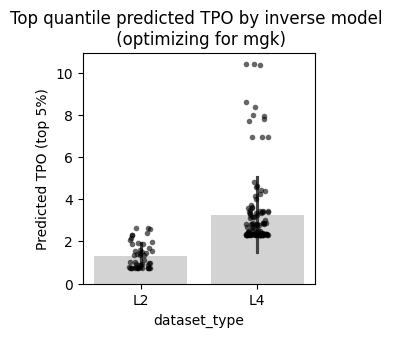

In [13]:
quantile_cutoff = 0.95  # top 5% — adjust as needed

# get the top-quantile threshold for each dataset
thresh_l2 = mgkpro_l2["tpo_[ng_ml]"].quantile(quantile_cutoff)
thresh_l4 = mgkpro_l4["tpo_[ng_ml]"].quantile(quantile_cutoff)

# subset to just the top-quantile rows
top_l2 = mgkpro_l2.loc[mgkpro_l2["tpo_[ng_ml]"] >= thresh_l2, ["tpo_[ng_ml]"]].assign(dataset_type="L2")
top_l4 = mgkpro_l4.loc[mgkpro_l4["tpo_[ng_ml]"] >= thresh_l4, ["tpo_[ng_ml]"]].assign(dataset_type="L4")

top_tpo_df = pd.concat([top_l2, top_l4], ignore_index=True)

plt.figure(figsize=(3, 3))
sns.barplot(
    data=top_tpo_df,
    x="dataset_type",
    y="tpo_[ng_ml]",
    color="lightgray",
    errorbar="sd"
)
sns.stripplot(
    data=top_tpo_df,
    x="dataset_type",
    y="tpo_[ng_ml]",
    color="black",
    size=4,
    jitter=True,
    alpha=0.6
)
plt.title("Top quantile predicted TPO by inverse model \n (optimizing for mgk)")
plt.ylabel("Predicted TPO (top 5%)")
plt.savefig("distribution_tpo_mgk.png", dpi=500)
plt.show()

In [14]:
# to_plot_tpo_size_ery = {"dataset_type": ["L2", "L4"], 
#                        "Max. predicted TPO": [erypro_l2["tpo_[ng_ml]"].max(), erypro_l4["tpo_[ng_ml]"].max()]}

# plt.figure(figsize=(3,3))
# sns.barplot(to_plot_tpo_size_ery, x="dataset_type", y="Max. predicted TPO")
# plt.title("Max TPO prediction by inverse model \n (optimizing for mgk)")
# plt.show()

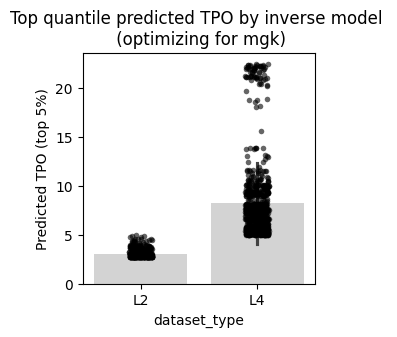

In [15]:
quantile_cutoff = 0.95  # top 5% — adjust as needed

# get the top-quantile threshold for each dataset
thresh_l2 = erypro_l2["tpo_[ng_ml]"].quantile(quantile_cutoff)
thresh_l4 = erypro_l4["tpo_[ng_ml]"].quantile(quantile_cutoff)

# subset to just the top-quantile rows
top_l2 = erypro_l2.loc[erypro_l2["tpo_[ng_ml]"] >= thresh_l2, ["tpo_[ng_ml]"]].assign(dataset_type="L2")
top_l4 = erypro_l4.loc[erypro_l4["tpo_[ng_ml]"] >= thresh_l4, ["tpo_[ng_ml]"]].assign(dataset_type="L4")

top_tpo_df = pd.concat([top_l2, top_l4], ignore_index=True)

plt.figure(figsize=(3, 3))
sns.barplot(
    data=top_tpo_df,
    x="dataset_type",
    y="tpo_[ng_ml]",
    color="lightgray",
    errorbar="sd"
)
sns.stripplot(
    data=top_tpo_df,
    x="dataset_type",
    y="tpo_[ng_ml]",
    color="black",
    size=4,
    jitter=True,
    alpha=0.6
)
plt.title("Top quantile predicted TPO by inverse model \n (optimizing for mgk)")
plt.ylabel("Predicted TPO (top 5%)")
plt.savefig("distribution_tpo_ery.png", dpi=500)
plt.show()

## Plot PCAs

In [16]:
# # Set global figure params — dpi_save controls resolution of saved files specifically
# sc.set_figure_params(dpi=500, dpi_save=500, figsize=(3, 3))

# # Optional: set output directory (defaults to ./figures/)
# sc.settings.figdir = "./figures"

# # mgkpro_l2_filtered = mgkpro_l2[mgkpro_l2["late_MgkPro_prop"] > 0.10]
# X_l2 = mgkpro_l2.loc[:, protocol_cols].values
# adata_l2 = sc.AnnData(X=X_l2.copy(), obs=mgkpro_l2)
# sc.pp.log1p(adata_l2)
# sc.pp.pca(adata_l2)


# sc.pl.pca(adata_l2, s=200, color="butyzamide_[nm]", vmax=100, frameon=False,
#           cmap="plasma", save="_butyzamide.png")
# sc.pl.pca(adata_l2, s=200, color="tpo_[ng_ml]", vmax=3, frameon=False,
#           cmap="plasma", save="_tpo.png")
# sc.pl.pca(adata_l2, s=200, color="late_MgkPro_prop", frameon=False,
#           cmap="plasma", save="_late_mgkpro_prop.png", vmin=0, vmax=1)

# sc.set_figure_params(dpi=80, dpi_save=80, figsize=(3, 3))

## Check heatmaps

In [17]:
mgkpro_prot = np.log1p(mgkpro_l4.loc[:, protocol_cols_l4])
late_mgkpro_prop = mgkpro_l4["late_MgkPro_prop"]

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


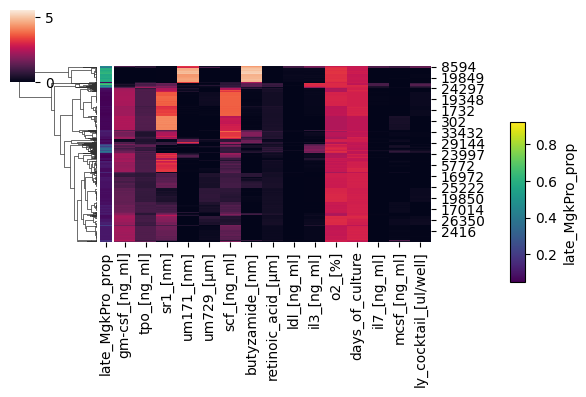

In [18]:
# Map the proportion values to colors using a continuous colormap
norm = Normalize(vmin=late_mgkpro_prop.min(), vmax=late_mgkpro_prop.max())
cmap = cm.viridis  # choose any colormap you like, e.g. "coolwarm", "magma"
row_colors = late_mgkpro_prop.map(lambda x: cmap(norm(x)))

g = sns.clustermap(
    mgkpro_prot,
    row_cluster=True,
    col_cluster=False,
    row_colors=row_colors,
    figsize=(5, 4),
    
)

# Add a separate colorbar legend for the row_colors annotation
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = g.fig.add_axes([1.02, 0.3, 0.03, 0.4])  # [left, bottom, width, height]
g.fig.colorbar(sm, cax=cbar_ax, label="late_MgkPro_prop")

plt.show()

## Check uncertainties

<Axes: xlabel='late_MgkPro_prop', ylabel='target_ct_loss_std'>

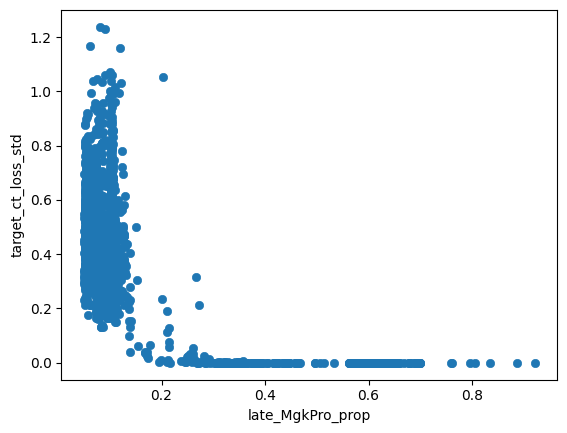

In [19]:
sns.scatterplot(mgkpro_l4, 
               x="late_MgkPro_prop", 
               y="target_ct_loss_std", 
               edgecolor=None)

In [20]:
# 1. Get the linkage used for the row dendrogram
row_linkage = g.dendrogram_row.linkage

# 2. Cut the tree into k clusters (tune this by eye from the dendrogram)
n_clusters = 5
row_clusters = fcluster(row_linkage, t=n_clusters, criterion='maxclust')

# 3. Build a dataframe linking each row (sample) to its cluster + its proportion value
cluster_df = pd.DataFrame({
    'cluster': row_clusters,
    'late_MgkPro_prop': late_mgkpro_prop.values
}, index=mgkpro_prot.index)

# 4. Check which cluster(s) have the highest average proportion
cluster_summary = cluster_df.groupby('cluster')['late_MgkPro_prop'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(cluster_summary)

# 5. Pull out the actual samples in the top cluster(s)
top_cluster_id = cluster_summary.index[0]
high_prop_samples = cluster_df[cluster_df['cluster'] == top_cluster_id]
print(high_prop_samples)

             mean  count
cluster                 
1        0.571800    242
3        0.570864     63
5        0.111103   1490
4        0.066499    754
2        0.053982      2
      cluster  late_MgkPro_prop
7799        1          0.921419
9899        1          0.887766
4391        1          0.833832
9241        1          0.805482
8999        1          0.796753
...       ...               ...
664         1          0.073406
2114        1          0.072267
414         1          0.065836
964         1          0.063903
2314        1          0.063333

[242 rows x 2 columns]


In [63]:
cluster_df.groupby("cluster").max()

,late_MgkPro_prop
cluster,
1,0.921419
2,0.054000
3,0.699960
4,0.125167
5,0.441586


Check if clusters are the ones we think

## Manually curate solutions for different clusters 

### Cluster 1

In [22]:
mgkpro_l4_cl1 = mgkpro_l4.loc[cluster_df[cluster_df.cluster==1].index]

In [23]:
mgkpro_l4_cl1 = mgkpro_l4_cl1.sort_values(by="target_ct_loss_std").head(20)

In [24]:
mgkpro_l4_cl1_best = mgkpro_l4_cl1.iloc[:3]

In [25]:
mgkpro_l4_cl1_best.loc[:, protocol_cols_l4]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well]
7799,0.00000,0.833168,0.000000,20.903702,0.000000,0.000000,120.850044,0.088747,1.553431,3.324857,24.678715,13.016206,2.219325,1.545006,3.743832
9899,0.00000,0.876597,0.076935,17.193460,0.000000,0.044511,102.322044,0.000000,1.816322,3.807152,20.266071,14.583728,2.084001,1.183632,2.950829
4391,0.06132,0.406102,0.022512,35.383080,0.121377,0.025384,103.786064,0.113043,1.337162,2.680783,20.635720,12.136278,1.521441,0.349087,1.297908


In [26]:
mgkpro_l4_cl1_best.loc[:, "sr1_[nm]"] = 0
mgkpro_l4_cl1_best.loc[:, "retinoic_acid_[µm]"] = 0
mgkpro_l4_cl1_best.loc[:, "ldl_[ng_ml]"] = 0
mgkpro_l4_cl1_best.loc[:, "il3_[ng_ml]"] = 0
mgkpro_l4_cl1_best.loc[:, "mcsf_[ng_ml]"] = 0
mgkpro_l4_cl1_best.loc[:, "ly_cocktail_[ul/well]"] = 0

In [27]:
mgkpro_l4_cl1_best.loc[:, protocol_cols_l4]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well]
7799,0.00000,0.833168,0.0,20.903702,0.000000,0.000000,120.850044,0.0,0.0,0.0,24.678715,13.016206,2.219325,0.0,0.0
9899,0.00000,0.876597,0.0,17.193460,0.000000,0.044511,102.322044,0.0,0.0,0.0,20.266071,14.583728,2.084001,0.0,0.0
4391,0.06132,0.406102,0.0,35.383080,0.121377,0.025384,103.786064,0.0,0.0,0.0,20.635720,12.136278,1.521441,0.0,0.0


In [28]:
# mgkpro_l4_cl1_best.to_csv("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/loop4_inverse_solutions/cl1.csv")

### Cluster 3

In [29]:
mgkpro_l4_cl3 = mgkpro_l4.loc[cluster_df[cluster_df.cluster==3].index]

In [30]:
mgkpro_l4_cl3 = mgkpro_l4_cl3.sort_values(by="target_ct_loss_std")

In [31]:
mgkpro_l4_cl3

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],...,cfg:constraints:c_scheduler_kwargs:vmax,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well],loss,target_ct_loss_std,target_ct_loss_mean,ct_prop_total_variance,late_MgkPro_prop,filtering_step
31898,0.549127,1.964082,3.196429,0.000000,0.000000,0.800167,2.227567,1.293531,0.000000,21.229424,...,7.5,1.762936,0.000000,2.566815,5.266889,0.000000,0.000000,0.000617,0.699960,pass
30198,0.563556,2.131621,2.735577,0.000000,0.000000,0.780762,2.644671,1.405906,0.000000,24.868690,...,15.0,1.754239,0.000000,2.072785,4.965259,0.000000,0.000000,0.000626,0.699123,pass
29348,0.468723,1.644391,3.055277,0.000000,0.002032,0.944602,2.629330,1.273756,0.000000,22.627190,...,15.0,1.739975,0.000000,2.331378,5.107383,0.000000,0.000000,0.001000,0.698800,pass
28998,0.577794,1.671912,3.138781,0.000000,0.007002,0.794753,2.802424,1.388654,0.000000,22.894968,...,15.0,1.672586,0.000000,2.132159,5.012892,0.000000,0.000000,0.001333,0.697234,pass
29648,0.571307,1.763434,3.537425,0.000000,0.000000,0.874257,2.745207,1.310235,0.000000,21.644726,...,15.0,1.563241,0.000000,2.053574,5.124737,0.000000,0.000000,0.000888,0.693918,pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8569,2.077305,6.959678,3.857464,0.331210,0.000000,2.274763,0.242306,0.075640,0.118476,8.241891,...,15.0,0.268035,0.168677,0.621617,10.792711,0.000102,0.000172,0.001170,0.351400,pass
2898,0.270899,1.995455,3.119179,0.340260,0.716604,1.149349,2.899404,1.130963,0.078590,20.255291,...,15.0,1.847424,0.000000,2.310387,7.414473,0.000113,0.000198,0.001812,0.442814,pass
12069,1.824639,6.953861,4.422018,0.000000,0.113727,2.302753,0.364078,0.404370,0.000000,6.275891,...,15.0,0.350668,0.233667,0.489827,11.756198,0.000178,0.000221,0.001786,0.356570,pass
7498,0.156355,2.031957,2.688749,0.308617,1.027512,1.403700,4.585451,0.997734,0.056265,19.520117,...,15.0,2.203930,0.000000,2.585911,8.191094,0.000249,0.000361,0.001244,0.393704,pass


In [32]:
mgkpro_l4_cl3_best = mgkpro_l4_cl3.iloc[:3]

In [33]:
mgkpro_l4_cl3_best.loc[:, protocol_cols_l4]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well]
31898,0.549127,1.964082,3.196429,0.0,0.000000,0.800167,2.227567,1.293531,0.0,21.229424,21.143341,12.151219,1.762936,0.0,2.566815
30198,0.563556,2.131621,2.735577,0.0,0.000000,0.780762,2.644671,1.405906,0.0,24.868690,20.236902,12.137424,1.754239,0.0,2.072785
29348,0.468723,1.644391,3.055277,0.0,0.002032,0.944602,2.629330,1.273756,0.0,22.627190,20.567263,12.053964,1.739975,0.0,2.331378


In [34]:
mgkpro_l4_cl3_best.loc[:, "um729_[µm]"] = 0
mgkpro_l4_cl3_best.loc[:, "il7_[ng_ml]"] = 0

In [35]:
mgkpro_l4_cl3_best.loc[:, protocol_cols_l4]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well]
31898,0.549127,1.964082,3.196429,0.0,0.0,0.800167,2.227567,1.293531,0.0,21.229424,21.143341,12.151219,0.0,0.0,2.566815
30198,0.563556,2.131621,2.735577,0.0,0.0,0.780762,2.644671,1.405906,0.0,24.868690,20.236902,12.137424,0.0,0.0,2.072785
29348,0.468723,1.644391,3.055277,0.0,0.0,0.944602,2.629330,1.273756,0.0,22.627190,20.567263,12.053964,0.0,0.0,2.331378


In [36]:
# mgkpro_l4_cl3_best.to_csv("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/loop4_inverse_solutions/cl3.csv")

### Cluster 5

In [37]:
mgkpro_l4_cl5 = mgkpro_l4.loc[cluster_df[cluster_df.cluster==5].index]

In [38]:
mgkpro_l4_cl5 = mgkpro_l4_cl5.sort_values(by="target_ct_loss_std")

In [39]:
mgkpro_l4_cl5.head(10).loc[:, protocol_cols_l4]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well]
30646,1.798191,2.294847,0.792262,0.000000,0.000000,1.291456,1.031444,0.582721,0.000000,6.115390,18.893574,12.308289,0.000000,0.000000,1.632883
11996,4.086691,2.164193,0.575051,0.000000,0.000000,1.184775,1.116918,0.449283,0.044096,4.585468,19.745632,12.023194,0.028943,1.081858,0.626070
3966,4.410151,2.116560,0.210980,0.000000,0.000000,0.981020,0.708585,1.108926,0.000000,4.258054,20.264008,12.031683,0.039481,0.602282,0.656455
4902,4.545822,1.816781,0.778111,0.021658,0.000000,0.561281,0.831304,1.680110,0.000000,4.395772,19.831661,12.776072,0.014251,2.235983,0.024123
35100,2.864462,1.280272,0.000000,0.000000,0.000000,0.887102,0.000000,0.981292,0.001098,5.359933,19.340720,12.436114,0.000000,0.190904,0.097319
11897,2.846477,1.149697,0.026758,0.079753,0.000000,1.251725,0.217146,0.731554,0.022113,4.729100,19.685392,12.415577,0.013619,0.563052,0.094806
8963,2.529609,1.384030,1.163614,0.000000,0.056225,0.921241,0.888414,0.822256,0.000000,5.600771,18.396986,13.802917,0.101527,0.640148,0.429559
13150,4.859429,1.266617,0.109732,0.000000,0.000000,1.018791,0.787128,0.668838,0.057294,4.162146,18.470192,13.439571,0.072402,0.809138,0.902678
30422,1.579312,1.269120,0.000000,0.000000,0.000000,1.088327,0.000000,0.699007,0.000000,4.331668,20.147516,12.016790,0.000000,0.000000,0.012010
34997,1.969747,1.366682,0.000000,0.000000,0.000000,1.061675,0.000000,1.151510,0.000000,5.122130,19.112986,12.566624,0.000000,0.000000,0.165554


In [40]:
mgkpro_l4_cl5_best = mgkpro_l4_cl5.iloc[:3]

In [41]:
mgkpro_l4_cl5_best.loc[:, protocol_cols_l4]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well]
30646,1.798191,2.294847,0.792262,0.0,0.0,1.291456,1.031444,0.582721,0.000000,6.115390,18.893574,12.308289,0.000000,0.000000,1.632883
11996,4.086691,2.164193,0.575051,0.0,0.0,1.184775,1.116918,0.449283,0.044096,4.585468,19.745632,12.023194,0.028943,1.081858,0.626070
3966,4.410151,2.116560,0.210980,0.0,0.0,0.981020,0.708585,1.108926,0.000000,4.258054,20.264008,12.031683,0.039481,0.602282,0.656455


In [42]:
mgkpro_l4_cl5_best.loc[:, "ldl_[ng_ml]"] = 0
mgkpro_l4_cl5_best.loc[:, "il7_[ng_ml]"] = 0

In [43]:
# mgkpro_l4_cl5_best.to_csv("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/loop4_inverse_solutions/cl5.csv")

## PCA with clusters

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_2366206/4065852442.py:27: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(


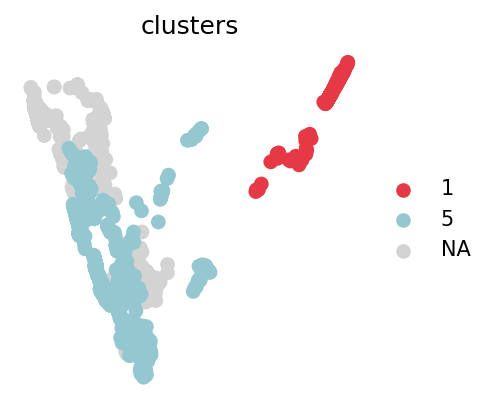

/tmp/ipykernel_2366206/4065852442.py:36: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(


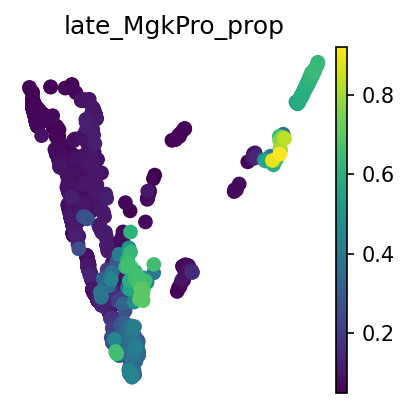

In [78]:
import scanpy as sc

# Make sure figures are saved to your desired directory
sc.settings.figdir = "./figures"  # change to your preferred output folder

with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": 150}):
    X_l4 = mgkpro_prot.values
    adata_l4 = sc.AnnData(X=X_l4.copy(), obs=mgkpro_l4)
    adata_l4.obs["clusters"] = row_clusters
    adata_l4.obs["clusters"] = adata_l4.obs["clusters"].astype("category")
    sc.pp.pca(adata_l4)

    # Make sure the palette keys match the actual category dtype (str vs int)
    cluster_palette = {
        1: "#E63946",
        # 3: "#1D3557",
        5: "#94C7CF",
    }
    cats = adata_l4.obs["clusters"].cat.categories
    if cats.dtype == object or all(isinstance(c, str) for c in cats):
        cluster_palette = {str(k): v for k, v in cluster_palette.items()}

    # Give every category a color so scanpy's internal palette build doesn't KeyError
    all_colors = {c: "#CCCCCC" for c in cats}  # fallback grey for other clusters
    all_colors.update(cluster_palette)

    sc.pl.pca(
        adata_l4,
        s=200,
        color="clusters",
        frameon=False,
        groups=list(cluster_palette.keys()),
        palette=all_colors,
        save="_clusters.png",
    )
    sc.pl.pca(
        adata_l4,
        s=200,
        color="late_MgkPro_prop",
        frameon=False,
        save="_late_MgkPro_prop.png",
    )

## MgkPro prop filtered

In [45]:
# # Map the proportion values to colors using a continuous colormap
# norm = Normalize(vmin=late_mgkpro_prop.min(), vmax=late_mgkpro_prop.max())
# cmap = cm.Greys
# row_colors = late_mgkpro_prop.map(lambda x: cmap(norm(x)))

# g = sns.clustermap(
#     mgkpro_prot[late_mgkpro_prop > 0.20],
#     row_cluster=True,       # keep clustering the rows...
#     col_cluster=False,
#     row_colors=row_colors,
#     figsize=(5, 4),
#     cmap="Greys",
#     yticklabels=False,      # ...but hide the row labels
# )

# # ...and hide the dendrogram (clustering still happens, just not drawn)
# g.ax_row_dendrogram.set_visible(False)

# # Add a separate colorbar legend for the row_colors annotation
# sm = cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
# cbar_ax = g.fig.add_axes([1.02, 0.3, 0.03, 0.4])
# g.fig.colorbar(sm, cax=cbar_ax, label="late_MgkPro_prop")
# plt.savefig("heatmap_loop4.png", dpi=800)
# plt.show()

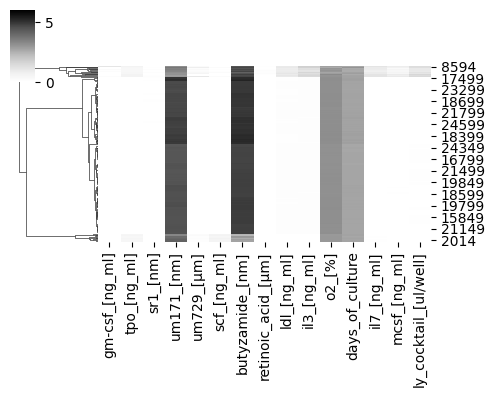

In [46]:
mgkpro_cl1 = mgkpro_l4.loc[cluster_df[cluster_df.cluster==1].index]

g = sns.clustermap(
    np.log1p(mgkpro_cl1.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    cmap="Grays",
    figsize=(5, 4),
    vmax=6
)

g.savefig("mgkpro_cl1.png", dpi=300, bbox_inches="tight")

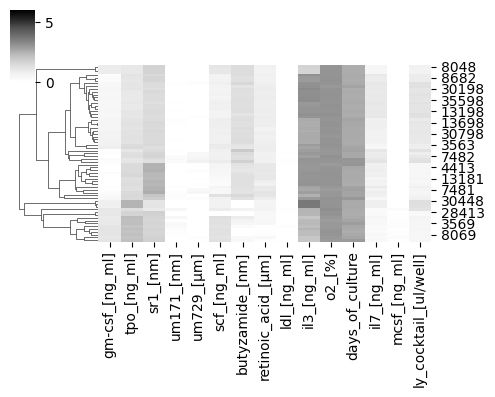

In [47]:
mgkpro_cl3 = mgkpro_l4.loc[cluster_df[cluster_df.cluster==3].index]

g = sns.clustermap(
    np.log1p(mgkpro_cl3.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    cmap="Grays",
    figsize=(5, 4),
    vmax=6
)

g.savefig("mgkpro_cl3.png", dpi=300, bbox_inches="tight")

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


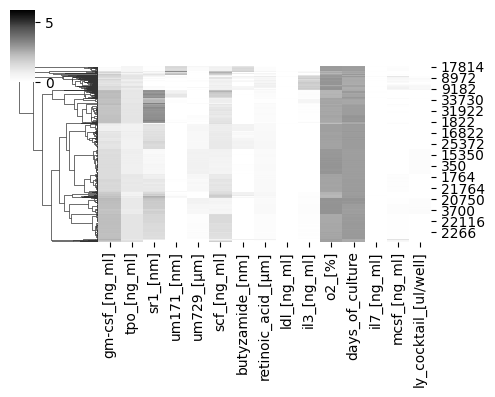

In [48]:
mgkpro_cl5 = mgkpro_l4.loc[cluster_df[cluster_df.cluster==5].index]

g = sns.clustermap(
    np.log1p(mgkpro_cl5.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    cmap="Grays",
    figsize=(5, 4),
    vmax=6
)

g.savefig("mgkpro_cl5.png", dpi=300, bbox_inches="tight")

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_2366206/2062227075.py:25: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(


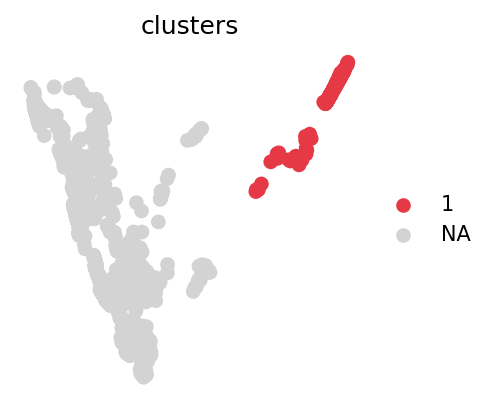

/tmp/ipykernel_2366206/2062227075.py:25: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(


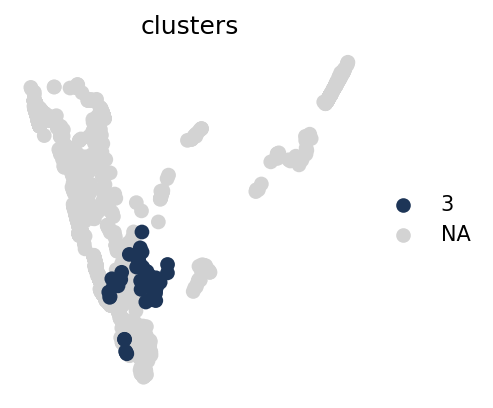

/tmp/ipykernel_2366206/2062227075.py:25: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(


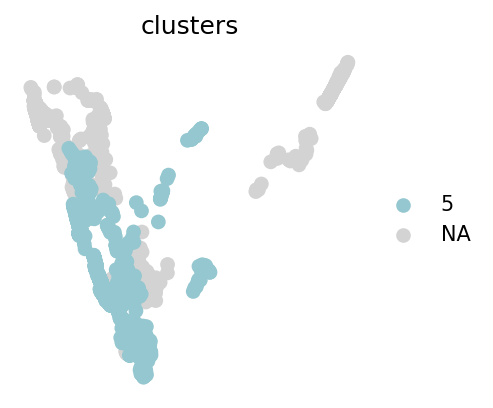

In [49]:
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": 150}):
    X_l4 = mgkpro_prot.values
    adata_l4 = sc.AnnData(X=X_l4.copy(), obs=mgkpro_l4)
    adata_l4.obs["clusters"] = row_clusters
    adata_l4.obs["clusters"] = adata_l4.obs["clusters"].astype("category")

    sc.pp.pca(adata_l4)

    # Make sure the palette keys match the actual category dtype (str vs int)
    cluster_palette = {
        1: "#E63946",
        3: "#1D3557",
        5: "#94C7CF",
    }
    cats = adata_l4.obs["clusters"].cat.categories
    if cats.dtype == object or all(isinstance(c, str) for c in cats):
        cluster_palette = {str(k): v for k, v in cluster_palette.items()}

    # Give every category a color so scanpy's internal palette build doesn't KeyError
    all_colors = {c: "#CCCCCC" for c in cats}  # fallback grey for other clusters
    all_colors.update(cluster_palette) 
    
    for cl in cluster_palette:

        sc.pl.pca(
            adata_l4,
            s=200,
            color="clusters",
            frameon=False,
            groups=[cl],
            palette=all_colors,
            save=f"late_MgkPro_prop_cl_{cl}.png"
        )

In [64]:
cluster_df

,cluster,late_MgkPro_prop
7799,1,0.921419
9899,1,0.887766
4391,1,0.833832
9241,1,0.805482
8999,1,0.796753
...,...,...
8297,5,0.050459
7197,5,0.050447
11297,5,0.050379
16313,5,0.050356


/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


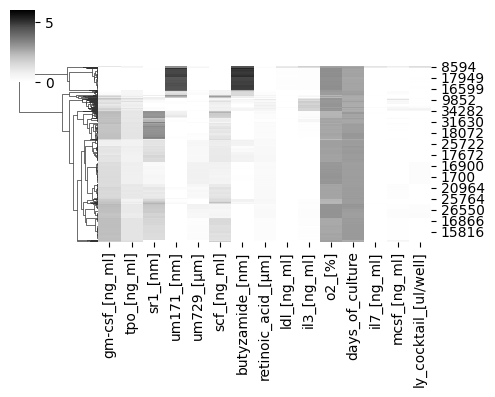

In [60]:
mgkpro_cls = mgkpro_l4.loc[cluster_df[cluster_df.cluster.isin([1, 5])].index]

g = sns.clustermap(
    np.log1p(mgkpro_cls.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    cmap="Grays",
    figsize=(5, 4),
    vmax=6
)

# g.savefig("mgkpro_cl5.png", dpi=300, bbox_inches="tight")

Original counts per cluster:
cluster
1     242
5    1490
dtype: int64

Counts above threshold per cluster:
cluster
1    231
5    138
dtype: int64

Selected 369 rows out of 1732 total


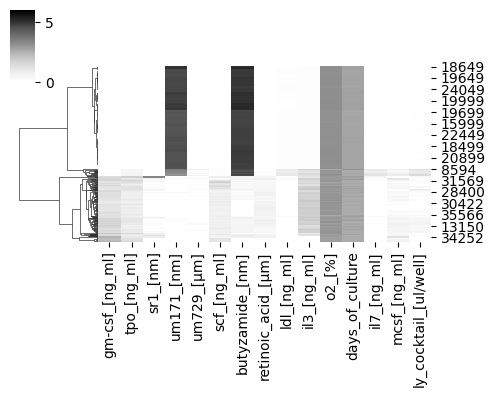

In [76]:
# --- Parameters ---
prop_threshold = 0.20

# --- Filter to clusters of interest, then threshold on proportion ---
sub = cluster_df[cluster_df.cluster.isin([1, 5])]
top_idx = sub[sub.late_MgkPro_prop > prop_threshold].index

# Sanity check
print("Original counts per cluster:")
print(sub.groupby("cluster").size())
print("\nCounts above threshold per cluster:")
print(sub.loc[top_idx].groupby("cluster").size())

# --- Subset the data matrix ---
mgkpro_cls = mgkpro_l4.loc[top_idx]
print(f"\nSelected {len(mgkpro_cls)} rows out of {len(sub)} total")

# --- Plot ---
g = sns.clustermap(
    np.log1p(mgkpro_cls.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    cmap="Grays",
    figsize=(5, 4),
    vmax=6
)

g.savefig("mgkpro_cl5_prop020.png", dpi=300, bbox_inches="tight")